In [1]:
pip install flask

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd          #numerical python
import matplotlib.pyplot as  plt  #Visualizatiom
import seaborn as  sns           #Visualization
import plotly.express as px        #Visualizatiom
from sklearn.preprocessing import LabelEncoder ,MinMaxScaler, StandardScaler         #Statistics
from flask import Flask , render_template , request , jsonify       #Deployement

In [4]:
TR = pd.read_csv('Travel.csv')       #find the influencing factors for conversion in Travel calls

In [5]:
pwd

'E:\\D_PYTHON RIDDHI\\EDA PROJECT_1'

# Cleaning 

#### STEP1 - See datatype and replace missing null values
#### STEP2 - now replace datatypes like float to int conversion
#### STEP3 - now plot BOX PLOT graph for each column to detect outliers
#### STEP4 - remove outliers using Zscore method

In [6]:
TR.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [7]:
# TR['Age'].astype(int)             #couldnt change due to null values

In [8]:
TR.isnull().sum()              #To check null values in all columns

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [9]:
for col in TR.columns:
    if TR[col].dtypes == 'object':   #for new pandas type 
        mode= TR[col].mode()[0]
        TR[col]=TR[col].fillna(mode)        # 0 = so that we get int\float
    else:
        mean = round(TR[col].mean(),0)
        TR[col]=TR[col].fillna(mean)

In [10]:
TR['Age'].mode()[0]

np.float64(38.0)

In [11]:
round(TR['Age'].mean(),0)

np.float64(38.0)

In [12]:
TR.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
TR.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [14]:
intcol=['Age','DurationOfPitch','NumberOfFollowups' ,'PreferredPropertyStar' ,'NumberOfTrips', 'NumberOfChildrenVisiting']

In [15]:
for col in intcol:
    TR[col]=TR[col].astype(int)

In [16]:
TR.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                           int64
TypeofContact                object
CityTier                      int64
DurationOfPitch               int64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups             int64
ProductPitched               object
PreferredPropertyStar         int64
MaritalStatus                object
NumberOfTrips                 int64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting      int64
Designation                  object
MonthlyIncome               float64
dtype: object

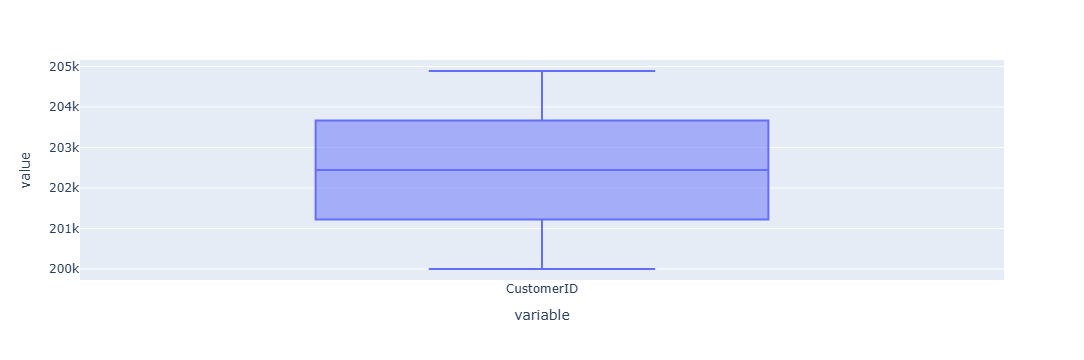

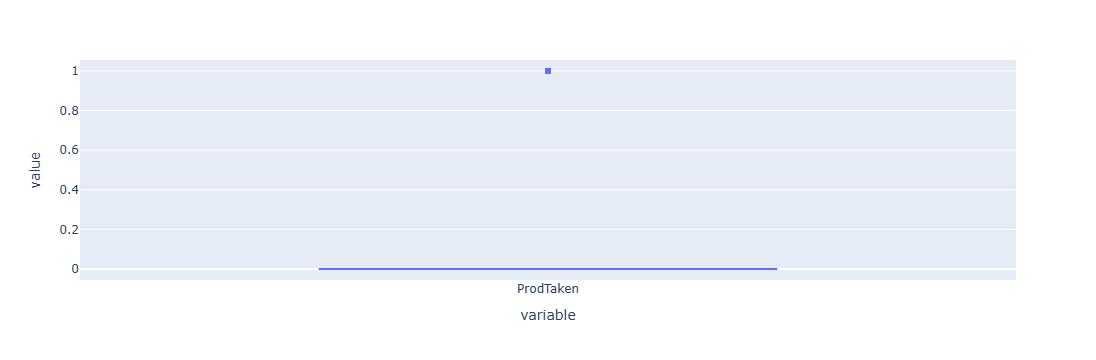

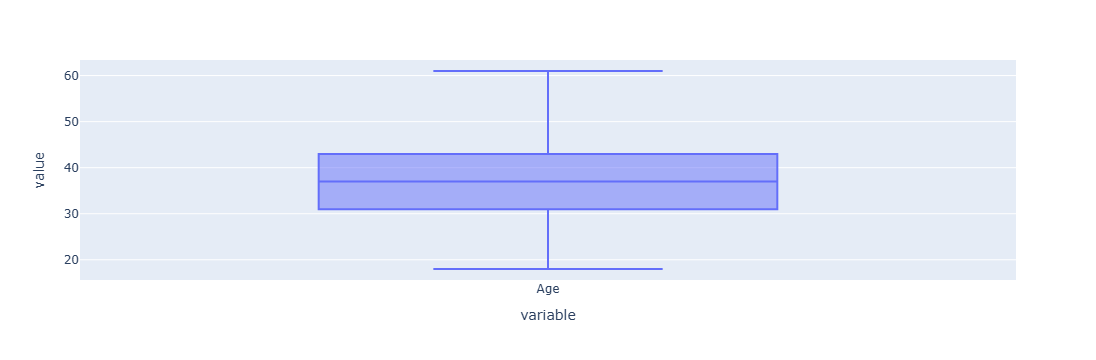

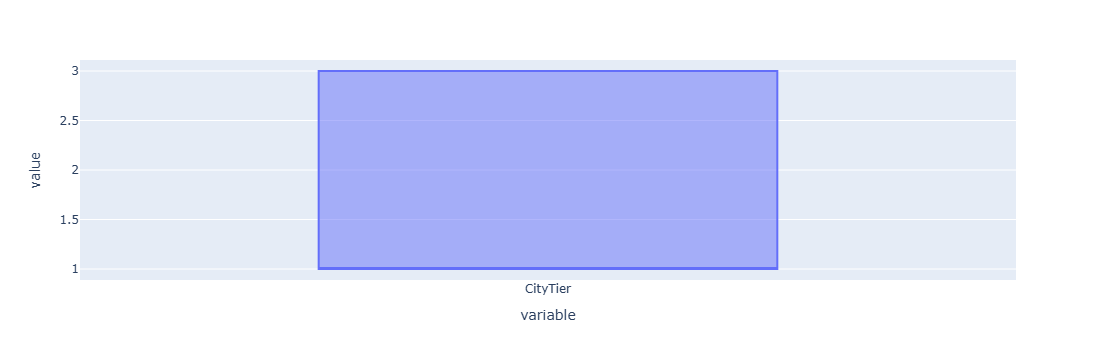

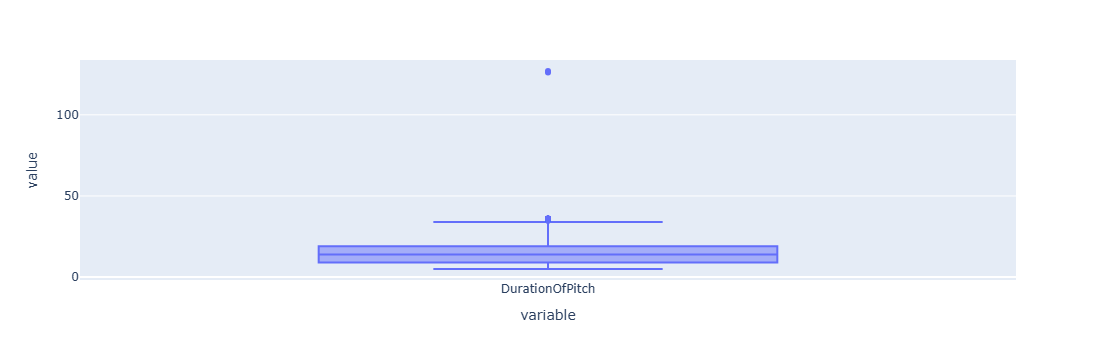

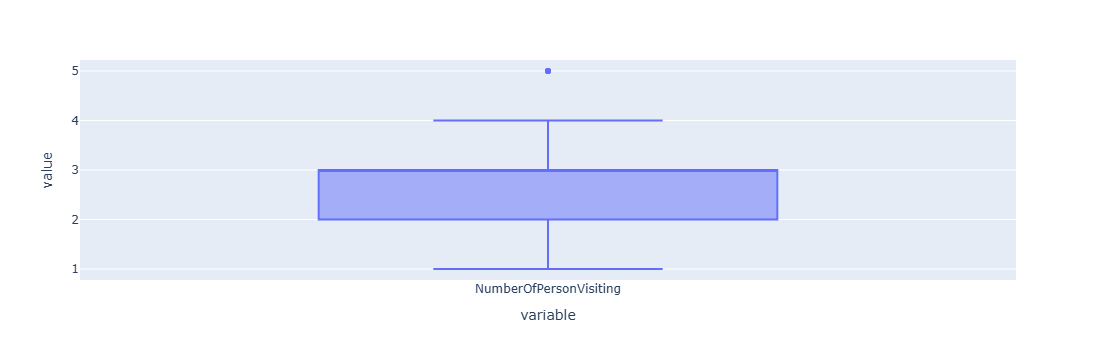

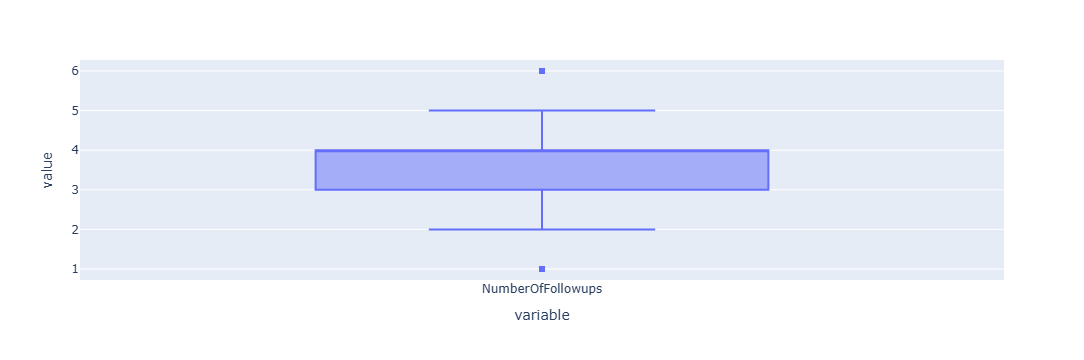

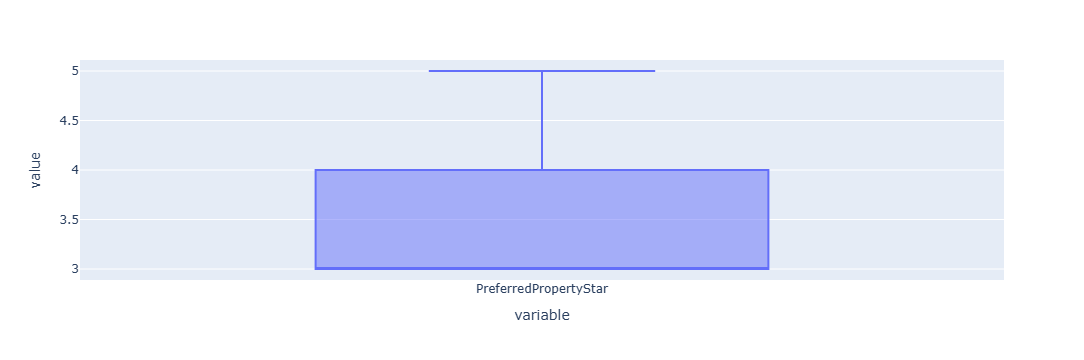

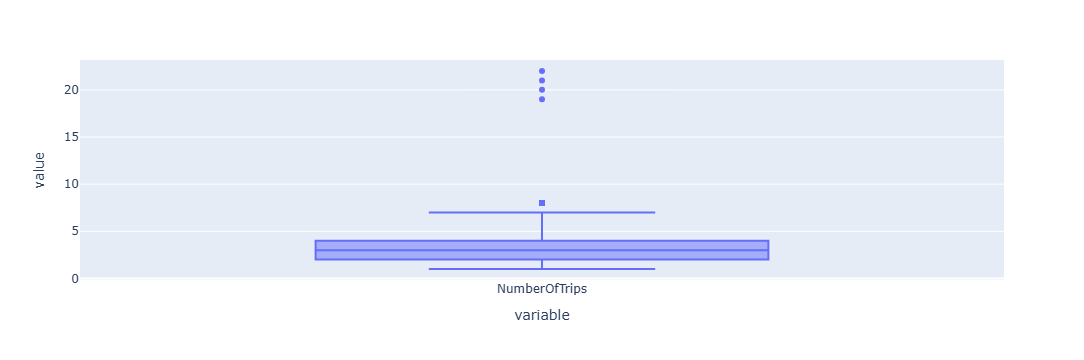

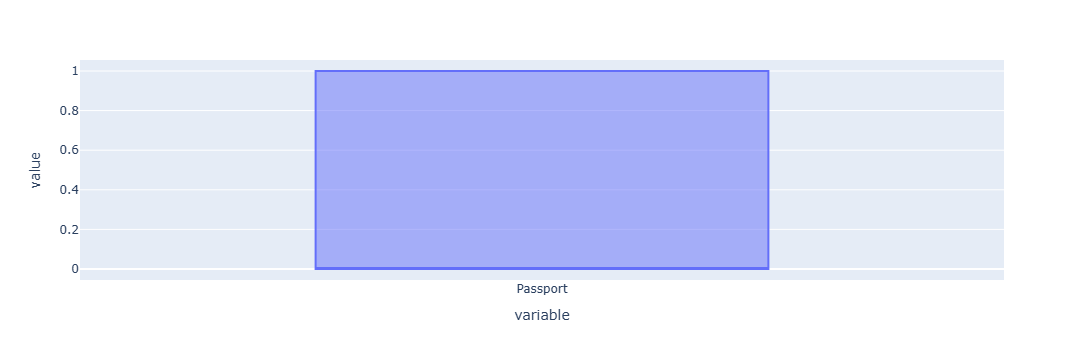

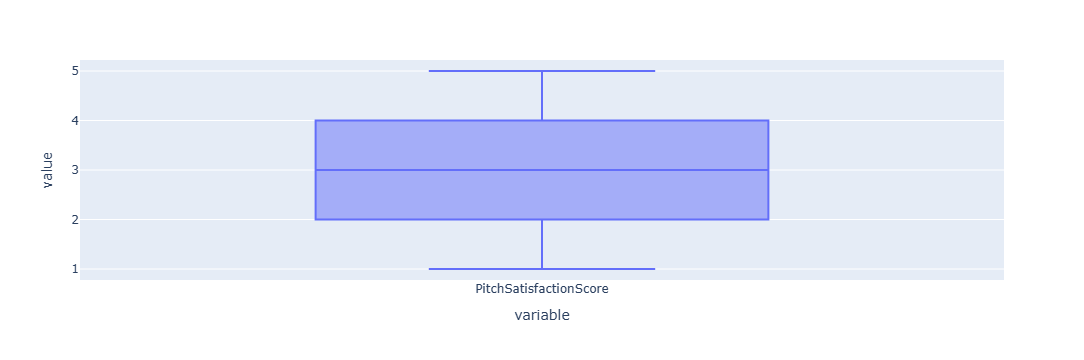

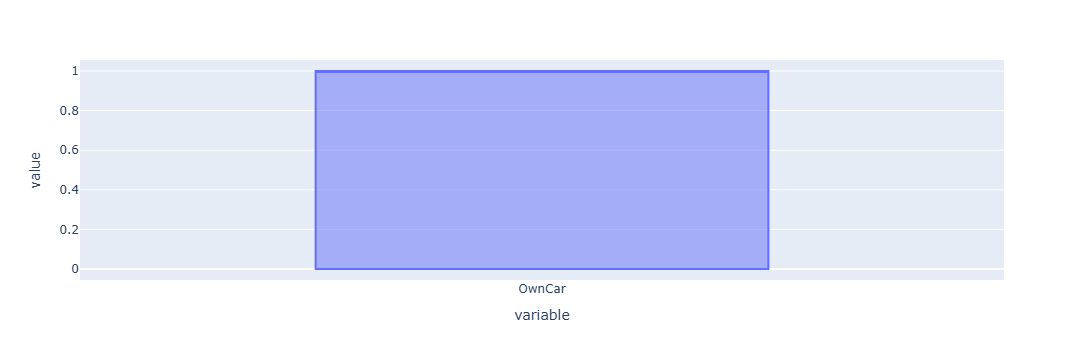

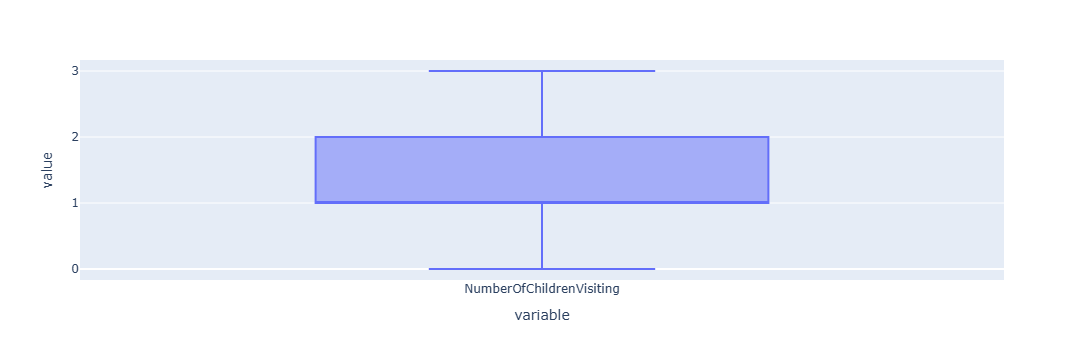

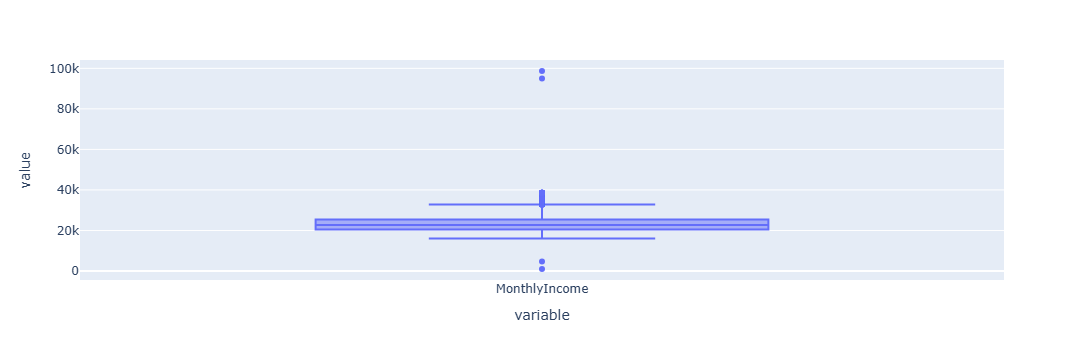

In [17]:
for col in TR.columns:
    if TR[col].dtypes!='object':
        fig=px.box(TR[col])
        fig.show()

##### Zscore Method [+-3 STD then there is no outliers with 99.7% data]             , z=x-mean/std , |z|>3

In [18]:
TR["Age"].std()

np.float64(9.098764236363126)

In [19]:
TR["Age"].std()*3

np.float64(27.29629270908938)

In [20]:
TR["Age"].mean()

np.float64(37.63972995090016)

In [21]:
TR["Age"].mean() + TR["Age"].std()*3              # upper bound

np.float64(64.93602265998953)

In [22]:
TR["Age"].mean() - TR["Age"].std()*3              # lower bound

np.float64(10.343437241810783)

# outliers removal loop

In [23]:
for col in TR.columns:
    if TR[col].dtypes!='object':               #new pandas its str
        Lower_Bound = TR[col].mean()-(TR[col].std()*3)             # Mean -(STD * 3)
        Upper_Bound = TR[col].mean()+(TR[col].std()*3)             # Mean +(STD * 3)
        TR=TR[ TR[col].between(Lower_Bound , Upper_Bound)]

In [24]:
TR.shape

(4878, 20)

In [25]:
(4878/4888)*100

99.79541734860884

In [26]:
TR.drop('CustomerID',axis=1, inplace = True)  #inplace for permanent changes

In [27]:
TRNUM = TR.select_dtypes([int,float])

<Axes: >

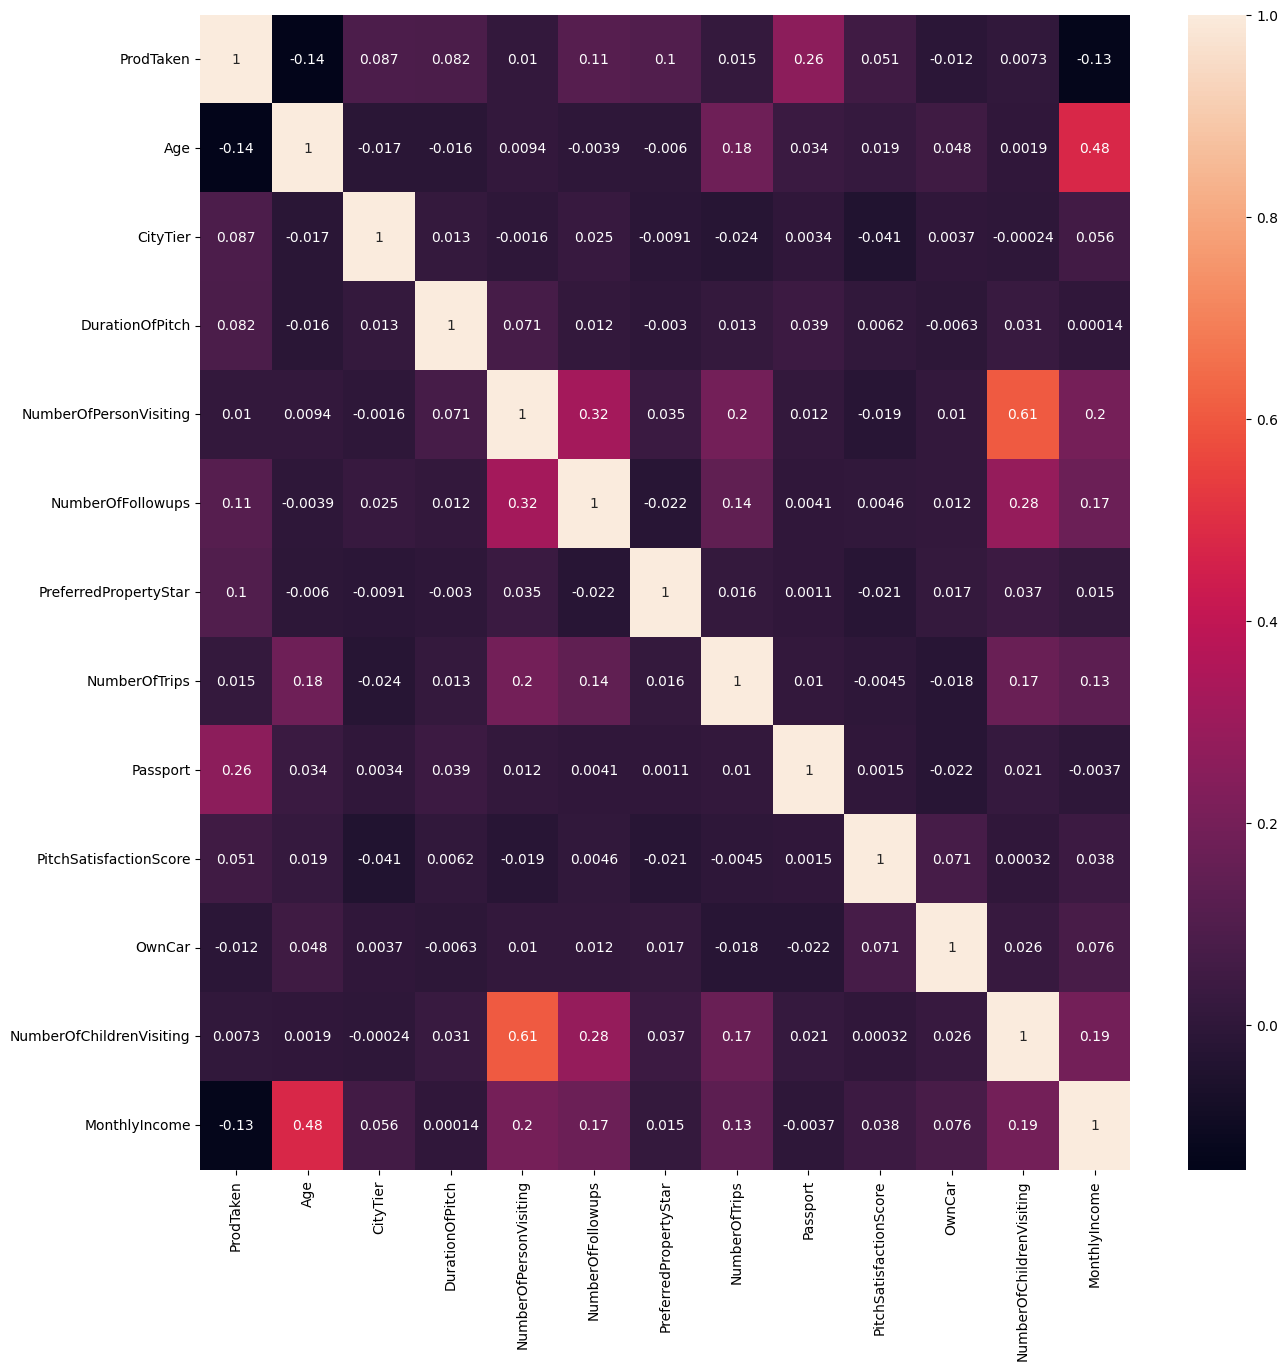

In [28]:
plt.figure(figsize=(15,15))
sns.heatmap(TRNUM.corr() , annot= True)

In [29]:
TR.drop('NumberOfChildrenVisiting',axis=1,inplace = True)   #drop kardiya isliye error show hoga ab 

# drop it cause its was the only column that showed Positive correlation (when x grows , y grows too linearly) 

# ANALYSIS

In [30]:
Conversion_Rate = TR['ProdTaken'].mean()

In [31]:
str(round(Conversion_Rate*100)) + '%'

'19%'

In [32]:
Total_Customers = TR.shape[0]

In [33]:
Total_Customers

4878

In [34]:
TR.dtypes     #checking customer id and numberofchildrenvisiting has been deleted

ProdTaken                   int64
Age                         int64
TypeofContact              object
CityTier                    int64
DurationOfPitch             int64
Occupation                 object
Gender                     object
NumberOfPersonVisiting      int64
NumberOfFollowups           int64
ProductPitched             object
PreferredPropertyStar       int64
MaritalStatus              object
NumberOfTrips               int64
Passport                    int64
PitchSatisfactionScore      int64
OwnCar                      int64
Designation                object
MonthlyIncome             float64
dtype: object

# VISUALIZATION

In [35]:
TR['ProdTakenCat']= TR['ProdTaken'].replace({0:"no", 1:"yes"})

In [36]:
TRG = TR.groupby(['TypeofContact','ProdTakenCat']).agg({'ProdTaken':'count'}).reset_index()      
#reset_index() gives us S.No. 

In [37]:
TRG1 = TR.groupby('TypeofContact').agg({'ProdTaken':'mean'})

In [38]:
TRG

,TypeofContact,ProdTakenCat,ProdTaken
0,Company Invited,no,1105
1,Company Invited,yes,308
2,Self Enquiry,no,2855
3,Self Enquiry,yes,610


In [39]:
TRG1

,ProdTaken
TypeofContact,
Company Invited,0.217976
Self Enquiry,0.176046


In [40]:
TRG_Complete = pd.merge(TRG,TRG1 , on ='TypeofContact')

In [41]:
TRG_Complete['conversion_rate']= round(TRG_Complete['ProdTaken_y']*100).astype(int).astype(str)+'%'

In [42]:
total=TRG[(TRG['TypeofContact']=='Company Invited')]['ProdTaken'].sum()

In [43]:
total

np.int64(1413)

In [44]:
converted =TRG[
    (  TRG['TypeofContact']=='Company Invited'  )
    &
    (  TRG['ProdTakenCat']=='yes'  )  ][
    'ProdTaken'][1]

In [45]:
conversion_rate= converted / total

In [46]:
conversion_rate

np.float64(0.21797593772116064)

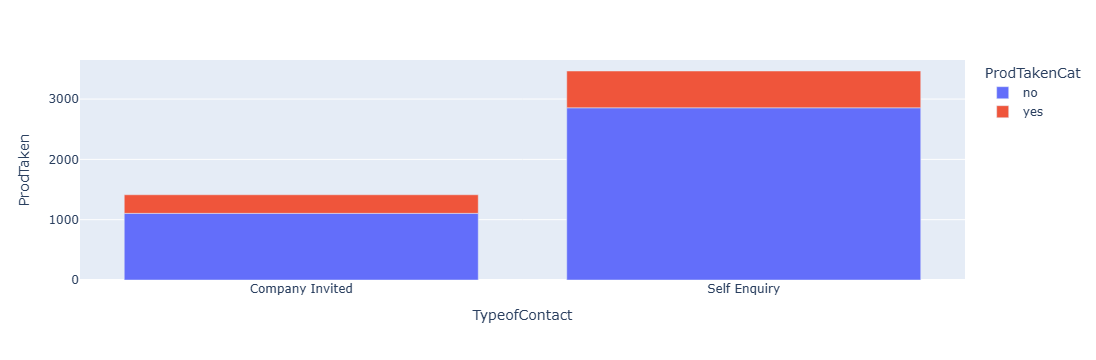

In [47]:
px.bar(TRG , x='TypeofContact', y='ProdTaken' , color='ProdTakenCat')

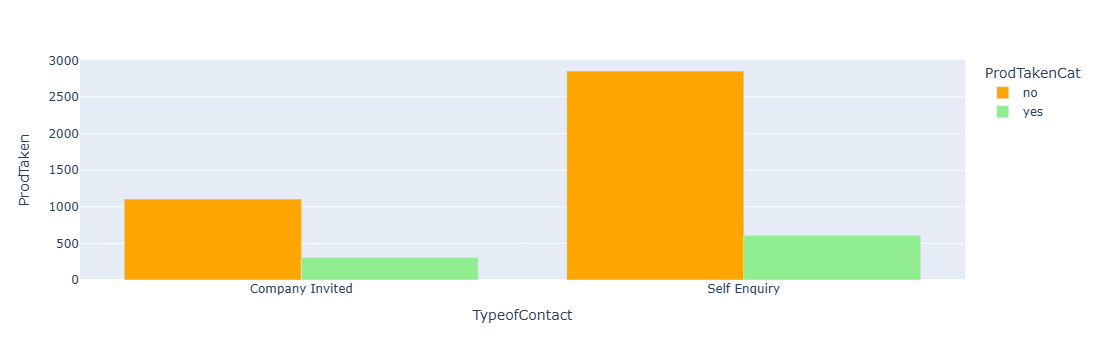

In [48]:
px.bar(TRG , x='TypeofContact', y='ProdTaken' , 
       color='ProdTakenCat' , 
       color_discrete_map={'no':'orange' ,'yes':'lightgreen'}  ,
       barmode='group')

In [49]:
TR.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'Designation', 'MonthlyIncome', 'ProdTakenCat'],
      dtype='object')

In [53]:
for col in TR.columns:  #loop for all columns
    if TR[col].dtypes == 'objects'and col!='ProdTakenCat':
        #running loop only with categorical columns
        TRG = TR.groupby([col,'ProdTakenCat']).agg({'ProdTaken':'count'}).reset_index()
        #to get count of records as per distinct category with yes and no both
        TRG1 = TR.groupby(col).agg({'ProdTaken':'mean'})
        # to get conversion percentages for distinct categort inside column
        TRG_Complete = pd.merge(TRG,TRG1 , on ='TypeofContact') 
        # merging both the tables
        TRG_Complete['conversion_rate']= round(TRG_Complete['ProdTaken_y']*100).astype(int).astype(str)+'%'
        #getting conversion values in percentage format
        fig = px.bar(TRG_Complete, #data
                     x=col, #x-axis
                     y='ProdTaken' , #count of yes and no
                     color='ProdTakenCat' , # yes and no
                     color_discrete_map={'no':'orange' ,'yes':'lightgreen'}  ,
                     barmode='group',
                     hover_data = 'conversion_rate') #conversion percentage on label
        fig.show()